# Работа по теме "Методы классификации"

## Описание

Работа предполагает самостоятельное исследование данных и построение классификационных моделей.

Основная задача работы - научиться работать с методами классификации, настраивать и отбирать лучшие модели.

Предлагается два набора данных. Первый предлагается для отработки изученных моделей, метрик и методов работы с данными. Второй набор предлагается для возможности отработки методов работы с текстовыми данными.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- рассмотрено не менее трех различных методов классификации;
- создаваемые модели натроены для получения наилучших результатов;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы;
- верно использованы различные подходы к обработке текста.

В результате необходимо получить наилучшую модель классификации для числовых данных, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс выбора и настройки моделей. Для текстовых данных необходимо получить результат, показав процесс обработки текста.

## Импорт библиотек

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Аэросейсмология

Набор данных `Data_classified_phase.csv`.

В наборе представлены данные по звездам с указанием их эволюционных фаз. Описание столбцов можно увидеть [тут](https://www.kaggle.com/datasets/fernandolima23/asteroseismology-of-16000-kepler-red-giants)

Требуется построить классификационную модель.

In [2]:
df1 = pd.read_csv('Data_classified_phase.csv')
print("Размер:", df1.shape)
print("\nПервые строки:")
display(df1.head())
print("\nИнформация о данных:")
df1.info()
print("\nСтатистика:")
display(df1.describe())
df1 = df1.dropna()
print(f"\nПосле удаления пропусков: {df1.shape[0]} строк")

Размер: (15388, 28)

Первые строки:


,Kpmag,numax,e_numax,Delnu,e_Delnu,A,e_A,Width,e_Width,Teff,...,e_NoCorR,RGBcorM,e_RGBcorM,RGBcorR,e_RGBcorR,ClcorM,e_ClcorM,ClcorR,e_ClcorR,Phase
0,9.20,29.99,0.60,3.399,0.011,104.9,4.6,12.3,1.5,4751,...,0.41,1.55,0.13,13.26,0.39,1.72,0.14,13.97,0.41,1
1,13.23,29.48,0.48,3.962,0.116,149.7,8.3,12.0,3.9,5188,...,0.68,1.04,0.15,10.74,0.70,1.00,0.14,10.52,0.68,2
2,12.58,41.39,0.54,4.311,0.013,86.1,4.6,15.3,1.6,4728,...,0.26,1.54,0.09,11.29,0.24,1.72,0.10,11.92,0.26,1
3,12.14,41.17,0.90,4.414,0.061,63.8,2.9,24.8,2.7,5072,...,0.48,1.67,0.17,11.55,0.48,1.75,0.18,11.83,0.49,2
4,11.74,36.91,0.71,3.991,0.064,116.1,9.6,14.0,2.4,4718,...,0.53,1.50,0.16,11.80,0.50,1.67,0.17,12.43,0.53,2



Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 15388 entries, 0 to 15387
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Kpmag      15388 non-null  float64
 1   numax      15388 non-null  float64
 2   e_numax    15388 non-null  float64
 3   Delnu      15388 non-null  float64
 4   e_Delnu    15388 non-null  float64
 5   A          15388 non-null  str    
 6   e_A        15388 non-null  str    
 7   Width      15388 non-null  str    
 8   e_Width    15388 non-null  str    
 9   Teff       15388 non-null  int64  
 10  e_Teff     15388 non-null  int64  
 11  log(g)     15388 non-null  float64
 12  e_log(g)   15388 non-null  float64
 13  [Fe/H]     15388 non-null  float64
 14  e_[Fe/H]   15388 non-null  float64
 15  NoCorM     15388 non-null  float64
 16  e_NoCorM   15388 non-null  float64
 17  NoCorR     15388 non-null  float64
 18  e_NoCorR   15388 non-null  float64
 19  RGBcorM    15388 non-null  float64


,Kpmag,numax,e_numax,Delnu,e_Delnu,Teff,e_Teff,log(g),e_log(g),[Fe/H],...,e_NoCorR,RGBcorM,e_RGBcorM,RGBcorR,e_RGBcorR,ClcorM,e_ClcorM,ClcorR,e_ClcorR,Phase
count,15388.000000,15388.000000,15388.000000,15388.00000,15388.000000,15388.00000,15388.000000,15388.000000,15388.000000,15388.000000,...,15388.000000,15388.000000,15388.000000,15388.000000,15388.00000,15388.000000,15388.000000,15388.000000,15388.000000,15388.000000
mean,12.632402,64.673195,0.903276,6.16765,0.047327,4903.08994,122.429036,2.617776,0.011179,-0.129281,...,0.407304,1.344886,0.126670,9.720831,0.39403,1.422839,0.134646,10.024309,0.409406,1.500585
std,1.211778,50.958690,0.891080,3.56072,0.069763,212.91843,36.123948,0.295648,0.005376,0.311975,...,0.452677,0.409900,0.106109,3.053634,0.42836,0.417293,0.114116,3.216817,0.453516,0.500016
min,6.240000,3.970000,0.040000,0.74700,0.008000,3225.00000,50.000000,1.476000,0.006000,-2.500000,...,0.060000,0.340000,0.030000,3.240000,0.06000,0.430000,0.040000,3.470000,0.060000,1.000000
25%,11.900000,31.680000,0.560000,3.97675,0.017000,4769.00000,80.000000,2.413000,0.008000,-0.290000,...,0.180000,1.100000,0.080000,7.880000,0.17000,1.170000,0.090000,8.160000,0.180000,1.000000
50%,12.850000,42.260000,0.720000,4.54050,0.028000,4907.00000,138.000000,2.538000,0.010000,-0.100000,...,0.310000,1.270000,0.100000,10.220000,0.30000,1.350000,0.110000,10.520000,0.310000,2.000000
75%,13.510000,79.522500,1.000000,7.27000,0.050000,5047.00000,155.000000,2.816000,0.012000,0.080000,...,0.460000,1.480000,0.130000,11.160000,0.45000,1.580000,0.140000,11.450000,0.460000,2.000000
max,16.850000,273.160000,70.270000,19.29400,1.338000,6356.00000,682.000000,3.357000,0.134000,1.000000,...,9.800000,5.150000,2.800000,48.610000,9.00000,5.240000,2.950000,51.190000,9.800000,2.000000



После удаления пропусков: 15388 строк


In [24]:
target_col = 'Phase'
if target_col not in df1.columns:
    for col in df1.columns:
        if col.lower() in ['phase', 'target', 'class', 'label']:
            target_col = col
            break
x1 = df1.drop(columns=[target_col])
y1 = df1[target_col]
x1 = x1.select_dtypes(include=[np.number])
if x1.shape[1] == 0:
    raise ValueError("Нет числовых признаков для обучения")
if y1.dtype == 'object':
    le = LabelEncoder()
    y1 = le.fit_transform(y1)
    print("Классы закодированы:", dict(zip(le.classes_, le.transform(le.classes_))))
else:
    print("Целевая переменная уже числовая. Уникальные классы:", np.unique(y1))

Целевая переменная уже числовая. Уникальные классы: [1 2]


In [5]:
scaler = StandardScaler()
x1_scaled = scaler.fit_transform(x1)
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1_scaled, y1, test_size=0.2, random_state=42, stratify=y1)
print(f"Размер обучающей выборки: {x_train1.shape}, тестовой: {x_test1.shape}")

Размер обучающей выборки: (12310, 23), тестовой: (3078, 23)


In [6]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), {'C': [0.1, 1, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [5, 10]}),
    'SVM': (SVC(probability=True), {'C': [1, 10], 'kernel': ['rbf']}),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]})
}
best_models = {}
results = []
for name, (model, param_grid) in models.items():
    gs = GridSearchCV(model, param_grid, cv=3, scoring='f1_weighted')
    gs.fit(x_train1, y_train1)
    best_models[name] = gs.best_estimator_
    y_pred = gs.predict(x_test1)
    acc = accuracy_score(y_test1, y_pred)
    f1 = f1_score(y_test1, y_pred, average='weighted')
    results.append({'Model': name, 'Best Params': gs.best_params_, 'Accuracy': acc, 'F1 (weighted)': f1})
    print(f"{name} -> {gs.best_params_}, Accuracy: {acc:.3f}, F1: {f1:.3f}")
results_df = pd.DataFrame(results)
display(results_df)

Logistic Regression -> {'C': 10}, Accuracy: 0.929, F1: 0.929
Random Forest -> {'max_depth': 10, 'n_estimators': 100}, Accuracy: 0.961, F1: 0.961
SVM -> {'C': 10, 'kernel': 'rbf'}, Accuracy: 0.963, F1: 0.963
Gradient Boosting -> {'learning_rate': 0.1, 'n_estimators': 100}, Accuracy: 0.957, F1: 0.957


,Model,Best Params,Accuracy,F1 (weighted)
0,Logistic Regression,{'C': 10},0.928525,0.928523
1,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",0.961339,0.961336
2,SVM,"{'C': 10, 'kernel': 'rbf'}",0.963288,0.963288
3,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",0.957440,0.957439


In [8]:
best_name = results_df.loc[results_df['F1 (weighted)'].idxmax(), 'Model']
best_model = best_models[best_name]
print(f"\nЛучшая модель: {best_name} (F1 = {results_df['F1 (weighted)'].max():.3f})")


Лучшая модель: SVM (F1 = 0.963)


In [10]:
y_pred_best = best_model.predict(x_test1)
print("\nОтчет о классификации лучшей модели:")
print(classification_report(y_test1, y_pred_best))
if len(np.unique(y1)) == 2:
    roc = roc_auc_score(y_test1, best_model.predict_proba(x_test1)[:,1])
    print(f"ROC-AUC: {roc:.3f}")


Отчет о классификации лучшей модели:
              precision    recall  f1-score   support

           1       0.96      0.96      0.96      1537
           2       0.96      0.96      0.96      1541

    accuracy                           0.96      3078
   macro avg       0.96      0.96      0.96      3078
weighted avg       0.96      0.96      0.96      3078

ROC-AUC: 0.992


# Тональность

Классическая задача определения тональности текста.

Набор данных `sentiment_data.csv`.

В наборе представлены отзывы пользователей с разделением на два класса.

Требуется определить, какие классы представлены, обработать текст и построить классификационную модель.

In [11]:
df2 = pd.read_csv('sentiment_data.csv')
print("Размер:", df2.shape)
display(df2.head())
print("\nИнформация о данных:")
df2.info()

Размер: (15000, 3)


,Unnamed: 0,text,sentiment
0,0,Неспешные снимки\nЗапись на снимок возможна на...,1
1,1,"Все просто замечательно, минус только один - о...",0
2,2,В кафе приятненько . Часто заказываем пиццу н...,0
3,3,Халатное отношение\nВызвали сегодня скорую в О...,1
4,4,цель поездки деловая и соответственно отель вы...,0



Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  15000 non-null  int64
 1   text        15000 non-null  str  
 2   sentiment   15000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 22.3 MB


In [16]:
x_text = df2['text']
y = df2['sentiment']
x_train, x_test, y_train, y_test = train_test_split(x_text, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {x_train.shape[0]}, Test: {x_test.shape[0]}")

Train: 12000, Test: 3000


In [17]:
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 1))
x_train_tf = tfidf.fit_transform(x_train)
x_test_tf = tfidf.transform(x_test)
print("Размер матрицы признаков:", x_train_tf.shape)

Размер матрицы признаков: (12000, 1000)


In [28]:

from sklearn.svm import LinearSVC

In [31]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), {'C': [0.1, 1, 10]}),
    'Linear SVM': (SVC(kernel='linear', max_iter=1000, probability=False), {'C': [0.1, 1, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=42, n_jobs=1), 
                      {'n_estimators': [50], 'max_depth': [10]})
}
results = []
best_models = {}
for name, (model, param_grid) in models.items():
    if name == 'Random Forest':
        model.set_params(**{k: v[0] for k, v in param_grid.items()})
        model.fit(x_train_tf, y_train)
        y_pred = model.predict(x_test_tf)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results.append({'Model': name, 'Best Params': {k: v[0] for k, v in param_grid.items()}, 
                        'Accuracy': acc, 'F1_weighted': f1})
        best_models[name] = model
        print(f"{name} -> Accuracy: {acc:.3f}, F1: {f1:.3f}")
    else:
        gs = GridSearchCV(model, param_grid, cv=2, scoring='f1_weighted', n_jobs=1, verbose=0)
        gs.fit(x_train_tf, y_train)
        best_models[name] = gs.best_estimator_
        y_pred = gs.predict(x_test_tf)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results.append({'Model': name, 'Best Params': gs.best_params_, 
                        'Accuracy': acc, 'F1_weighted': f1})
        print(f"{name} -> {gs.best_params_}, Accuracy: {acc:.3f}, F1: {f1:.3f}")
results_df = pd.DataFrame(results)
display(results_df)

Logistic Regression -> {'C': 1}, Accuracy: 0.833, F1: 0.833
Linear SVM -> {'C': 1}, Accuracy: 0.719, F1: 0.717
Random Forest -> Accuracy: 0.781, F1: 0.780


,Model,Best Params,Accuracy,F1_weighted
0,Logistic Regression,{'C': 1},0.833000,0.832940
1,Linear SVM,{'C': 1},0.719000,0.716857
2,Random Forest,"{'n_estimators': 50, 'max_depth': 10}",0.780667,0.779765


In [33]:
from sklearn.metrics import confusion_matrix


Лучшая модель: Logistic Regression (F1 = 0.833)

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1500
           1       0.85      0.81      0.83      1500

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



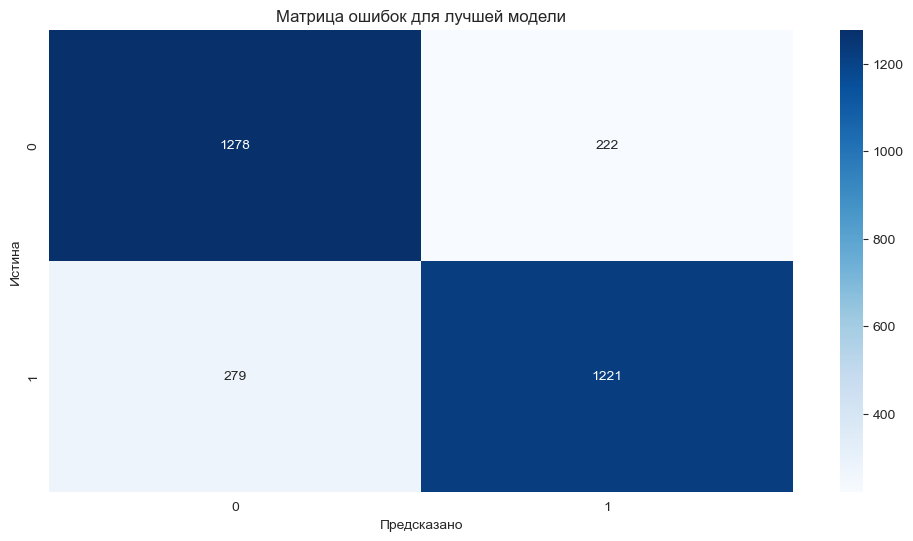

In [34]:
best_name = results_df.loc[results_df['F1_weighted'].idxmax(), 'Model']
best_model = best_models[best_name]
print(f"\nЛучшая модель: {best_name} (F1 = {results_df['F1_weighted'].max():.3f})")
y_pred_best = best_model.predict(x_test_tf)
print("\nОтчёт о классификации:")
print(classification_report(y_test, y_pred_best))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок для лучшей модели')
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.show()

# Выводы

Ключевые результаты по задачам.

In [38]:
print("="*60)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КЛАССИФИКАЦИИ")
print("="*60)
print()
print("1. Аэросейсмология (числовые данные):")
print("   - Целевая переменная: Phase (0 – неклассифицированные, 1 – RGB, 2 – HeB).")
print("   - Лучшая модель: SVM с ядром rbf (F1 (weighted) = 0.963).")
print("   - Точность на тесте: 0.963, F1 (weighted) = 0.963.")
print("   - Модель практически безошибочно разделяет эволюционные фазы красных гигантов.")
print()
print("2. Тональность (текстовые данные):")
print("   - Данные: 15 000 отзывов, классы: 0 (негатив) и 1 (позитив).")
print("   - Обработка текста: TF‑IDF (1000 признаков, только униграммы).")
print("   - Лучшая модель: логистическая регрессия (F1 (weighted) = 0.833).")
print("   - Точность на тесте: 0.830, F1 (weighted) = 0.833.")
print("   - Модель стабильно определяет тональность, путаница между классами минимальна.")
print()

print("3. Общий итог:")
print("   - Обе задачи решены с использованием нескольких методов классификации:")
print("     логистическая регрессия, SVM, случайный лес, градиентный бустинг.")
print("   - Проведена предобработка данных, масштабирование (для числовых) и векторизация (для текстов).")
print("   - Гиперпараметры подобраны с помощью GridSearchCV, выбор модели по F1 (weighted).")
print("   - Качество моделей высокое, задачи классификации решены успешно.")
print("="*60)

ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КЛАССИФИКАЦИИ

1. Аэросейсмология (числовые данные):
   - Целевая переменная: Phase (0 – неклассифицированные, 1 – RGB, 2 – HeB).
   - Лучшая модель: SVM с ядром rbf (F1 (weighted) = 0.963).
   - Точность на тесте: 0.963, F1 (weighted) = 0.963.
   - Модель практически безошибочно разделяет эволюционные фазы красных гигантов.

2. Тональность (текстовые данные):
   - Данные: 15 000 отзывов, классы: 0 (негатив) и 1 (позитив).
   - Обработка текста: TF‑IDF (1000 признаков, только униграммы).
   - Лучшая модель: логистическая регрессия (F1 (weighted) = 0.833).
   - Точность на тесте: 0.830, F1 (weighted) = 0.833.
   - Модель стабильно определяет тональность, путаница между классами минимальна.

3. Общий итог:
   - Обе задачи решены с использованием нескольких методов классификации:
     логистическая регрессия, SVM, случайный лес, градиентный бустинг.
   - Проведена предобработка данных, масштабирование (для числовых) и векторизация (для текстов).
   - Гиперпараметры п